# Mini Project 2
Nama: Faraday Barr Fatahillah

Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

#### Background

Cardio Vascular Disease (CVD) merupakan penyakit yang sangat mematikan dengan [tahun 2021 terdapat 20.5 Juta kematian dan terjadi di negara dengan pemasukan menengah ke bawah.](https://pmc.ncbi.nlm.nih.gov/articles/PMC10809869/) Penyebab utama kematian dari CVD adalah penyakit jantung iskemik dan stroke, yang disebabkan oleh faktor risiko perilaku dan metabolik seperti penggunaan tembakau, alkohol, kurang aktivitas fisik, tekanan darah tinggi, dan kadar glukosa darah tinggi.

#### Problem Statements

1. Kurangnya fasilitas intervensi lebih awal untuk prediksi dini.
2. Metode tradisional bergantung pada interpretasi manual.

#### Objective

1. Melakukan analisis statistika dan eksplorasi data terhadap dataset CVD untuk memahami distribusi data, pola, dan faktor-faktor yang paling berpengaruh.
2. Membangun dan membandingkan model Machine Learning (ML) untuk evaluasi efektivitas dalam memprediksi CVD dan melakukan evaluasi metrik accuracy, precision, F1-score, dan ROC-AUC.
3. Melakukan hyperparameter tuning untuk mendapatkan performa terbaik.
4. Menghasilkan insight yang dapat membantu tenaga medis atau masyarakat dalam pengambilan keputusan klinis cepat.

#### Import Library

In [30]:
#All library needed
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from xgboost import XGBClassifier


#### Load Dataset

In [68]:
#Load dataset
df = pd.read_csv('diabetes_bfrss.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [70]:
rows = []

for col in df.columns:
    rows.append({
        "Column": col,
        "Unique Values": df[col].unique()
    })

unique_table = pd.DataFrame(rows)
unique_table


,Column,Unique Values
0,Diabetes_012,"[0.0, 2.0, 1.0]"
1,HighBP,"[1.0, 0.0]"
2,HighChol,"[1.0, 0.0]"
3,CholCheck,"[1.0, 0.0]"
4,BMI,"[40.0, 25.0, 28.0, 27.0, 24.0, 30.0, 34.0, 26...."
5,Smoker,"[1.0, 0.0]"
6,Stroke,"[0.0, 1.0]"
7,HeartDiseaseorAttack,"[0.0, 1.0]"
8,PhysActivity,"[0.0, 1.0]"
9,Fruits,"[0.0, 1.0]"


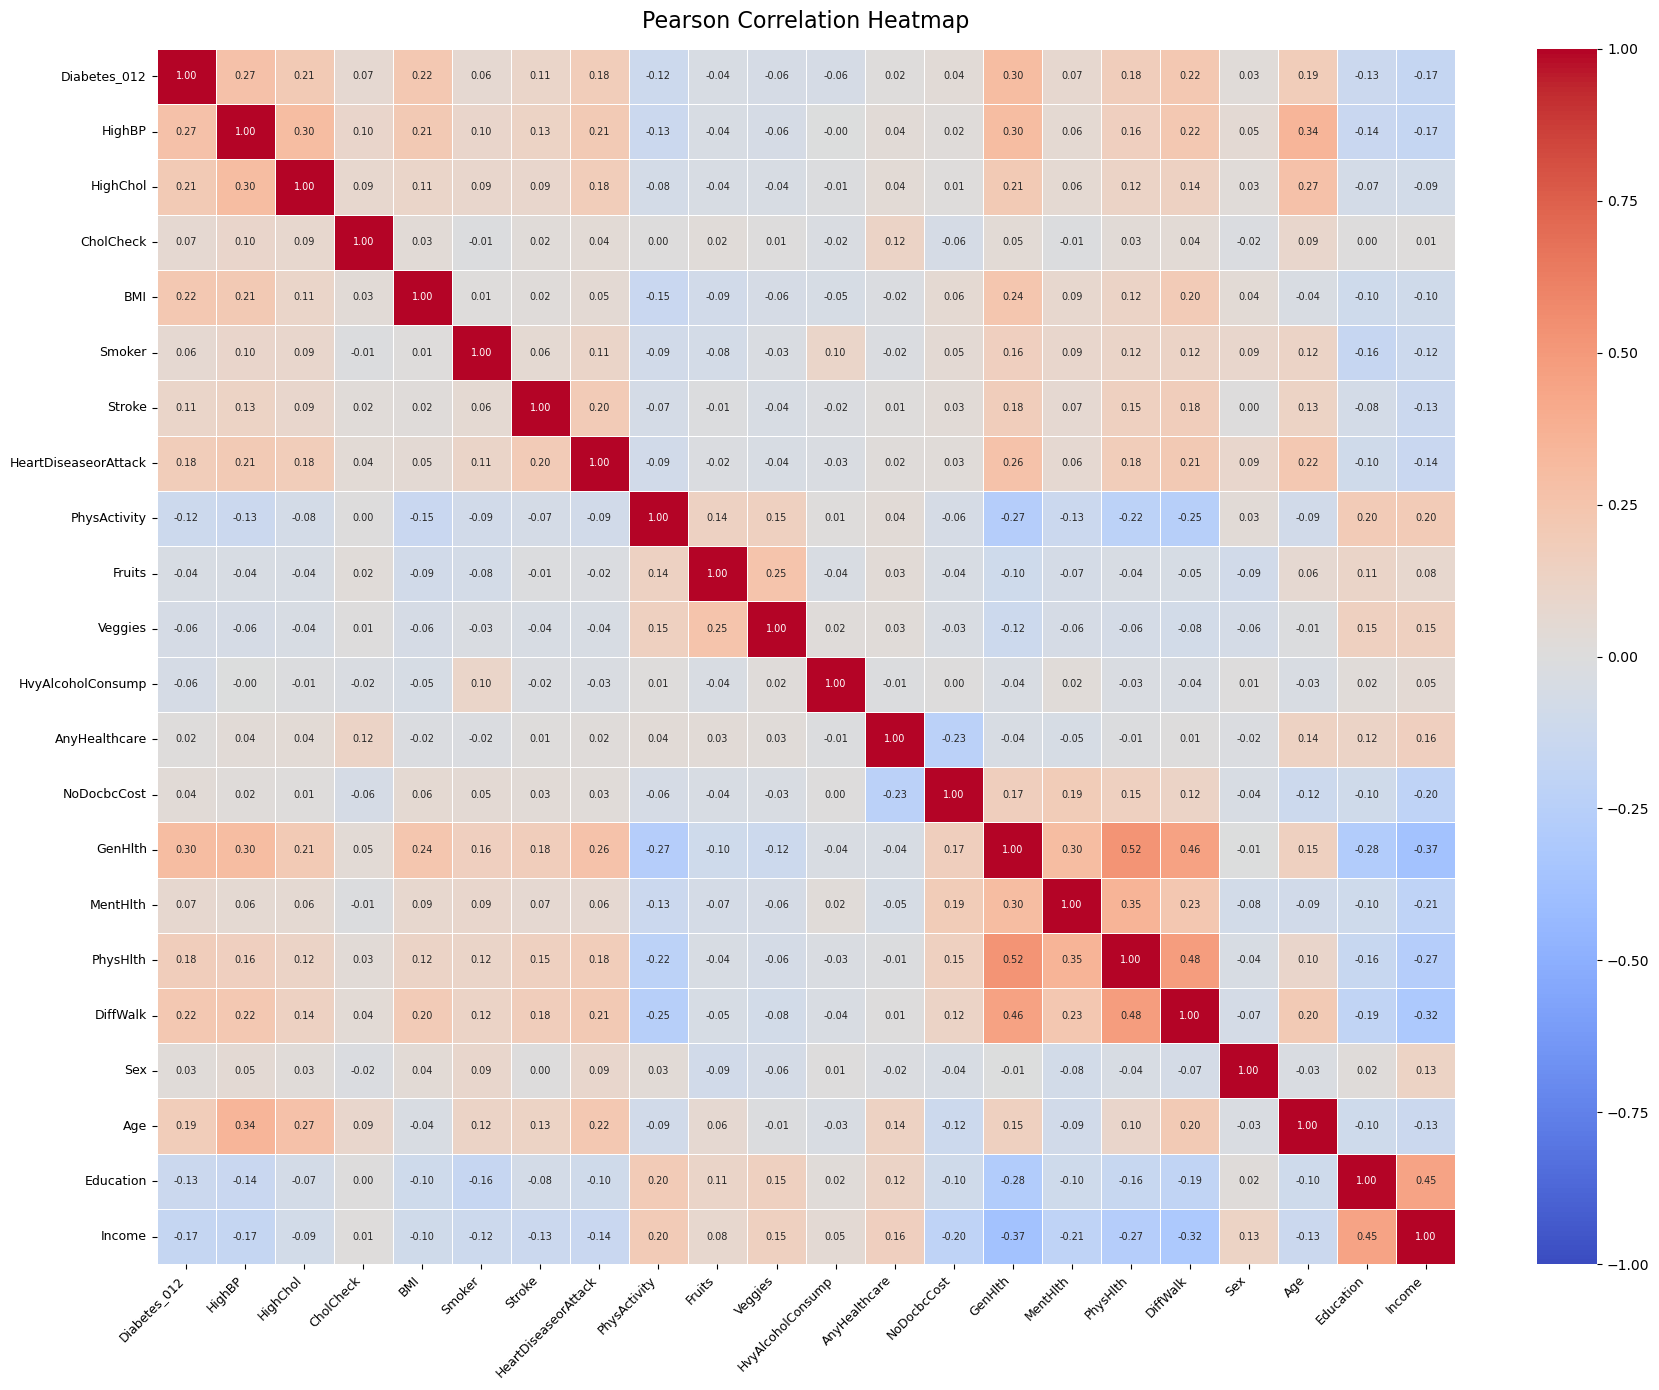

In [75]:
plt.figure(figsize=(18, 14))

cm = df.corr()

sns.heatmap(
    data=cm,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7}
)

plt.title('Pearson Correlation Heatmap', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Label per Column:
1. 'Diabates_012': Target, 0 = no diabetes, 1 = prediabetes, 2 = diabetes
2. 'HighBP': Binary, 0 = no high, BP 1 = high BP
3. 'HighChol': Binary, 0 = no high cholesterol, 1 = high cholesterol
4. 'CholCheck': Binary, 0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years
5. 'BMI': Float
6. 'Smoker': Binary, 0 = no, 1 = yes
7. 'Stroke': Binary, 0 = no, 1 = yes
8. 'HeartDiseaseorAttack, Binary 0 = no, 1 = yes
9. 'PhysActivity': Binary, 0 = no, 1 = yes
10. 'Fruits': Binary, 0 = no, 1 = yes
11. 'Veggies': Binary, 0 = no, 1 = yes
12. 'HvyAlcoholConsump': Binary, 0 = no, 1 = yes
13. 'AnyHealthCare': Binary, 0 = no, 1 = yes
14. 'NoDocbcCost': Binary, 0 = no, 1 = yes
15. 'GenHlth': Categorical, 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor
16. 'MentHlth': Float, scale 1-30 days
17. 'PhysHlth': Float, scale 1-30 days
18. 'DiffWalk': Binary, 0 = no, 1 = yes
19. 'Sex': Binary, 0 = female, 1 = male
20. 'Age': Categorical, 1 = 18-24, 9 = 60-64, 13 = 80 or older
21. 'Education': Categorical, 1 = Never attended school or only kindergarten, 2 = Grades 1 through 8 (Elementary), 3 = Grades 9 through 11 (Some high school), 4 = Grade 12 or GED (High school graduate), 5 = College 1 year to 3 years (Some college or technical school), 6 = College 4 years or more (College graduate)
22. 'Income': Categorical, 1 = less than $10,000, 5 = less than $35,000, 8 = $75,000 or more

#### Clean Dataset

In [71]:
df.isna().sum().sort_values(ascending=False)

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [77]:
df.astype('int64')

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0,1,1,1,45,0,0,0,0,1,...,1,0,3,0,5,0,1,5,6,7
253676,2,1,1,1,18,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,0,1,28,0,0,0,1,1,...,1,0,1,0,0,0,0,2,5,2
253678,0,1,0,1,23,0,0,0,0,1,...,1,0,3,0,0,0,1,7,5,1


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

#### Statistik Deskriptif

In [81]:
numerik = ['BMI', 'MentHlth', 'PhysHlth']

for col in numerik:
    print(f'Mean {col}: {df[col].mean()}')
    print(f'Median {col}: {df[col].median()}')
    print(f'Mode {col}: {df[col].mode()[0]}')
    print(f'Std {col}: {df[col].std()}')
    print(f'Q1 {col}: {df[col].quantile(0.25)}')
    print(f'Q3 {col}: {df[col].quantile(0.75)}')
    print(f'IQR {col}: {df[col].quantile(0.75) - df[col].quantile(0.25)}')
    print('')

Mean BMI: 28.382363607694735
Median BMI: 27.0
Mode BMI: 27.0
Std BMI: 6.608694201406008
Q1 BMI: 24.0
Q3 BMI: 31.0
IQR BMI: 7.0

Mean MentHlth: 3.1847721538946705
Median MentHlth: 0.0
Mode MentHlth: 0.0
Std MentHlth: 7.412846696196173
Q1 MentHlth: 0.0
Q3 MentHlth: 2.0
IQR MentHlth: 2.0

Mean PhysHlth: 4.2420805739514345
Median PhysHlth: 0.0
Mode PhysHlth: 0.0
Std PhysHlth: 8.717951307175127
Q1 PhysHlth: 0.0
Q3 PhysHlth: 3.0
IQR PhysHlth: 3.0



In [84]:
df[numerik].describe()

,BMI,MentHlth,PhysHlth
count,253680.000000,253680.000000,253680.000000
mean,28.382364,3.184772,4.242081
std,6.608694,7.412847,8.717951
min,12.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000
75%,31.000000,2.000000,3.000000
max,98.000000,30.000000,30.000000


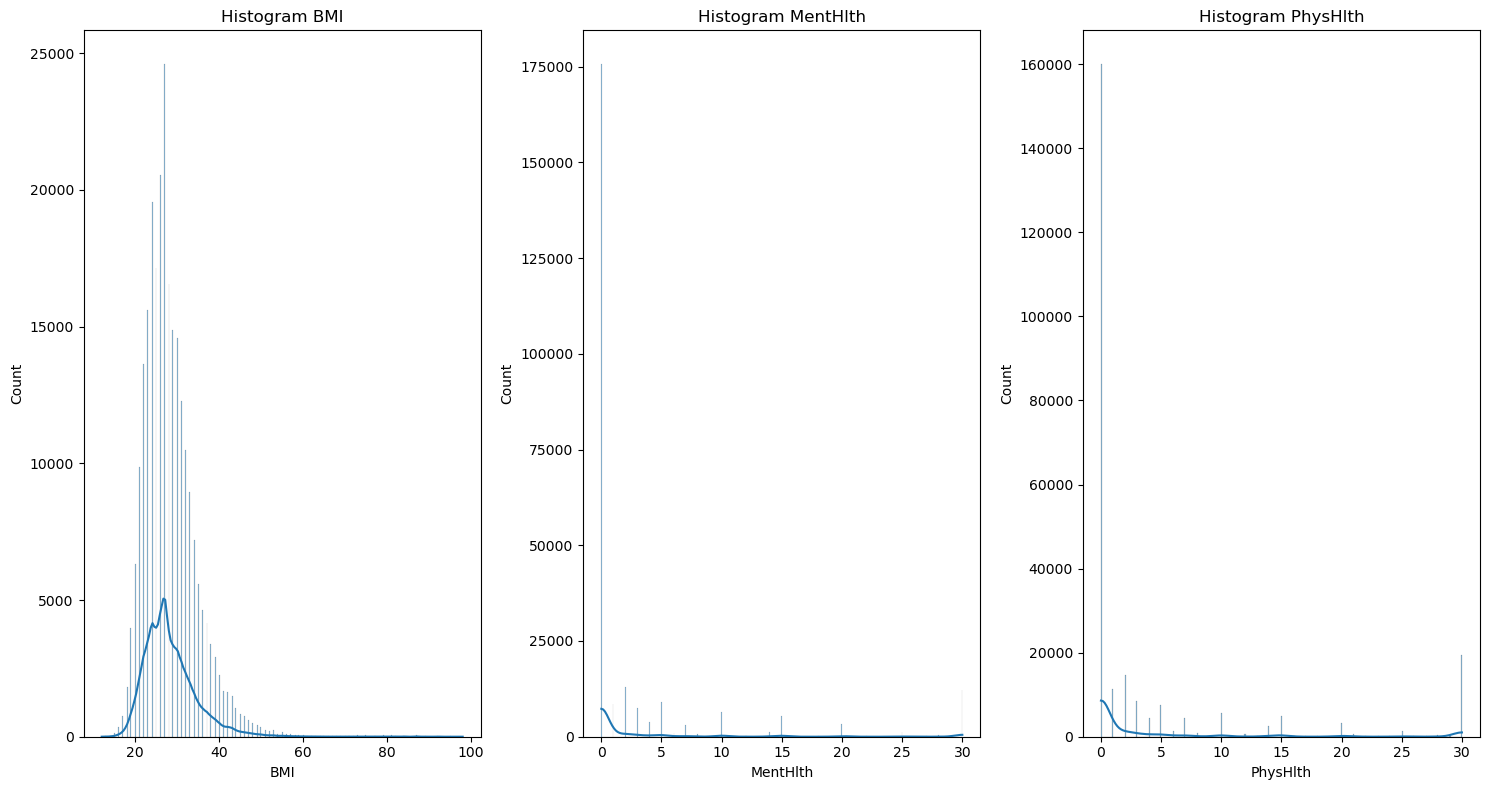

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerik):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram {col}')
    
plt.tight_layout()
plt.show()

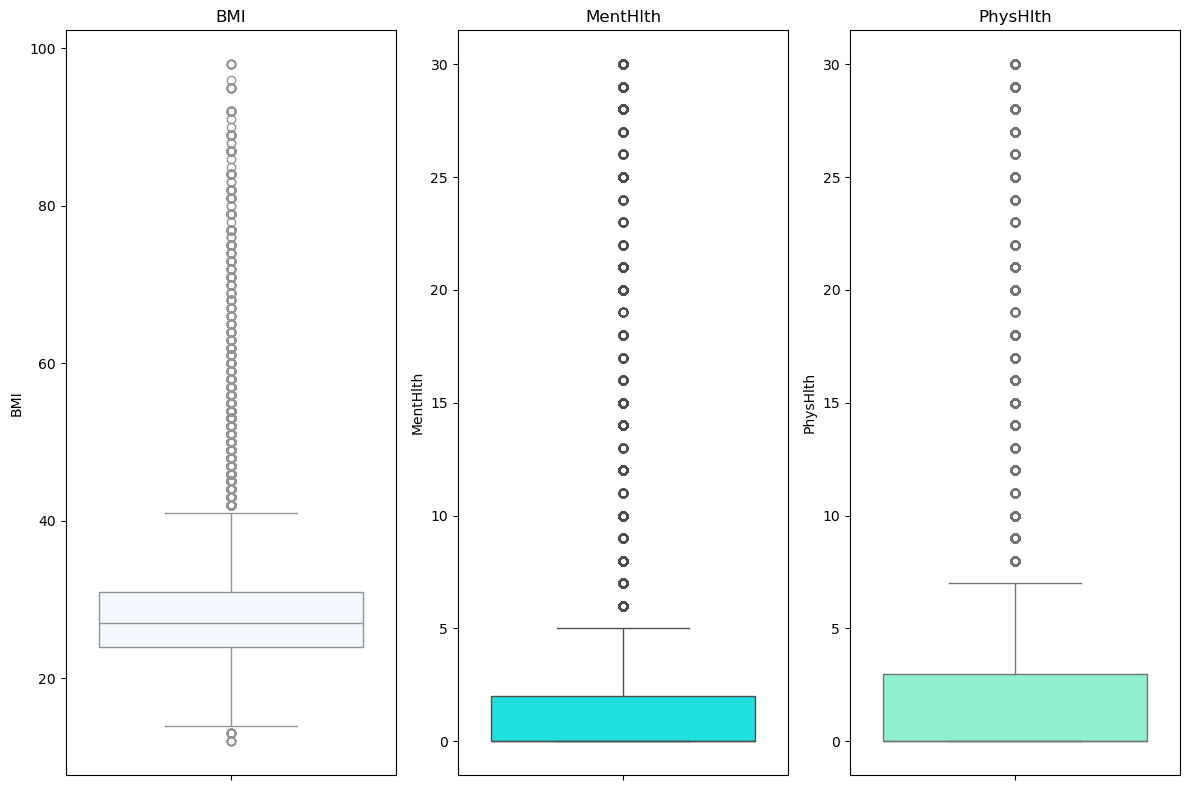

In [90]:
fig, ax = plt.subplots(1, 3 , figsize=(12,8))
ax = ax.flatten()

color = ['aliceblue', 'aqua', 'aquamarine']

for i, col in enumerate(numerik):
    sns.boxplot(data=df, y=col, ax=ax[i], color=color[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [48]:
X = df.drop(columns='cardio')
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_col = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
num_col = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo']

In [49]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, num_col),
        ('categorical', categorical_pipeline, cat_col)
    ],
    remainder='passthrough',
    verbose=True
)

In [50]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.0s


In [51]:
preprocessor.get_feature_names_out()

array(['numerical__age', 'numerical__gender', 'numerical__height',
       'numerical__weight', 'numerical__ap_hi', 'numerical__ap_lo',
       'categorical__cholesterol', 'categorical__gluc',
       'categorical__smoke', 'categorical__alco', 'categorical__active'],
      dtype=object)

In [52]:
X_train_preprocessed= pd.DataFrame(X_train_preprocessed, columns=preprocessor.get_feature_names_out())
X_test_preprocessed= pd.DataFrame(X_test_preprocessed, columns=preprocessor.get_feature_names_out())

In [53]:
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

data_train= pd.concat([X_train_preprocessed, y_train], axis=1)
data_test= pd.concat([X_test_preprocessed, y_test], axis=1)